<a href="https://colab.research.google.com/github/Clara3786/Project-Genome-Scale-CRISPR-Cas9-Knockout-Screening-in-Human-Cells/blob/main/Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## **Project card**

*Tove Brunell & Clara Carlborg*
<br><br>

**The paper:**
Genome-Scale CRISPR-Cas9 Knockout Screening in Human Cells
<br><br>

**The data object:**
The data is the proportion of frameshift and in-frame mutations after sgRNAs target the EGFP gene in HEK293T cells. After sgRNA has attached to the target, the lentiCRISPR mechanism can result in a deletion, insertion, or substitution in the EGFP gene, leading to a frameshift or in-frame mutation. The data were derived from Figure S2, B.
<br><br>

**The random variable chosen:**
Frame-shift mutation efficiency fraction.
<br><br>

**What the paper does:**
This paper consists of CRISPR-Cas9 experiments conducted on human melanoma cells to investigate potential genes that result in the nonfunctioning of the cancer medication vemurafenib.

The authors created a library of 64,751 different lentiviral vectors with unique sgRNAs that targeted a total of 18,080 genes in human cells. To determine whether the knockout of the gene targeted by a specific sgRNA affected vemurafenib function, the transduced cells were treated with vemurafenib, and the sgRNAs of the surviving cells were further investigated. This to get an idea of what genes are essential for the functioning of vemurafenib.

Before the final experiment was performed on the cancer cells, the lentiCRISPR mechanism had to be tested. To do this, they created six vectors, each consisting of a specific sgRNA for the enhanced green fluorescent protein (EGFP) gene. Each vector was transduced into a human embryonic kidney (HEK) 293T cell that contained one copy of the EGFP gene. If the sgRNA targets the EGFP gene, Cas9 will bind to the gene and make a dsDNA cut. The repair mechanism in the cell will try to repair the dsDNA break, and this can either result in a total repair or in an in-frame or frameshift mutation. If a frameshift mutation occurs, this often means that the gene is not functioning. After the experiment, the EGFP gene was deep sequenced, and it was shown that 92 ± 9% of the reads contained an insertion or deletion. The graph we will further investigate in this project is whether that insertion/deletion led to an in-frame or frameshift mutation. The fractions of these are shown in Figure S2, B in the paper.
<br><br>

**The generative model proposed:**
Binomial distribution: either we get a frameshift, or we get an in-frame mutation. Our randome variable *X* is the number of frameshifts and follows a binomial distribution. The formula for the binomial distribution is:
<br><br>
$$
X \sim \operatorname{Bin}(n,p)
$$

$$
P(X=k)=\binom{n}{k}p^k(1-p)^{n-k}
$$

where n is the number of successful outcomes, p is the probability of success and k is the expected number of successful outcomes.
<br><br>

**Parameters and assumptions:**
The parameter we want to estimate from the data is *p*. The probability of a frameshift mutation given that an indel mutation has occurred.

We assume in this case that all the different sgRNAs will have the same probability of creating a frameshift mutation. This is a large estimate, because in cells this probability depends on, for example, the sgRNA itself , where the Cas9 is going to cut, the repair mechanism, and the nucleotide sequence. Since we make this assumption, we can calculate and use the mean of p as a summary statistic. The mean and standard deviation of *p* from the data were 0.44 ± 0.13.
<br><br>

**The forward simulation:**
To simulate the data presented in Figure S2, B which shows the distribution of frameshift and in-frame mutations per sgRNA. For this, we use the Monte Carlo approach, so we draw a random number between 0 and 1 and check if it’s smaller than the *p* from the data. If this is true, we add a count to the number of frameshifts. For each sgRNA, we simulate 100 reads.
<br><br>

**The parameterization/fitting:**
To estimate the parameter, we use the negative log-likelihood (NLL) approach to find p for our binomial distribution. By using the data from the paper, we can estimate *p* by finding the minimum value of the negative log-likelihood function for a binomial distribution, with the number of reads n = 100 and the expected number of frameshifts k representing the data from Figure S2, B. We find the NLL minimum by doing a grid search of *p̂* from 0.2 to 0.8 with a step size of 0.001. The estimated p̂ with the corresponding standard deviation from this method was 0.435 ± 0.020.
<br><br>

**What/if the model adds to the paper:**
The forward simulation could be used in the future if you want to simulate the distribution of frameshift and in-frame mutations given that an indel has happened for the sgRNAs targeting the EGFP gene. So, you could do the simulation instead of the experiment, which saves time and money. However, since the number of indels occurring depends on a lot of parameters, including the target gene and sgRNA sequence, it may not be suitable to use this simulation for other sgRNAs targeting other genes.
<br><br>

**Model limitations/how it breaks:**
One major limitation of the model is that the variation of the *p* in the data is not visible in the bottom-up approach. This is shown in Figure 4 in the code. By assuming the binomial as the parametric function, we assume that all the sgRNAs have the same probability of creating a frameshift mutation. In reality, this is not true, as we mentioned above. If there were more data present about the individual reads for the sgRNAs, and the data did not just show the fraction of frameshifts and in-frame mutations, we could have created a model that accounts for different p-values for each sgRNA. That would have resulted in a model that represents the data better than the binomial model we used here.
<br><br>
**AI usage:**
AI has been used in this project for understanding of the paper, discussing ideas of models to use and debugging. AI was also used to read the data file from the GitHub repository into the project.ipynb file.
<br><br>

**Sources:**

Link to paper: https://www.science.org/doi/10.1126/science.1247005

Extra material, where Figure S2, B can be found: https://www.science.org/doi/suppl/10.1126/science.1247005/suppl_file/shalem.sm.pdf


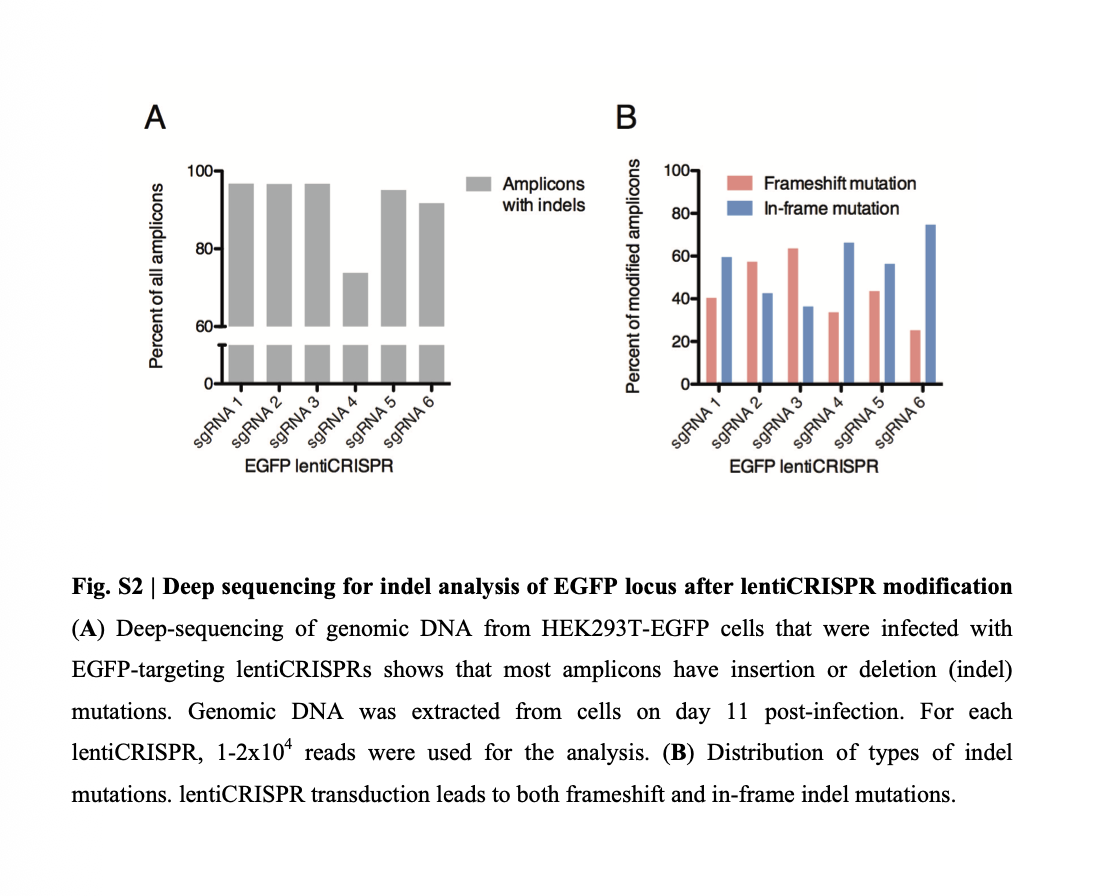

#The data

In [35]:
# Get datafile from repository

!git clone https://github.com/Clara3786/Project-Genome-Scale-CRISPR-Cas9-Knockout-Screening-in-Human-Cells.git

%cd /content/Project-Genome-Scale-CRISPR-Cas9-Knockout-Screening-in-Human-Cells

!git pull

fatal: destination path 'Project-Genome-Scale-CRISPR-Cas9-Knockout-Screening-in-Human-Cells' already exists and is not an empty directory.
/content/Project-Genome-Scale-CRISPR-Cas9-Knockout-Screening-in-Human-Cells
Already up to date.


In [36]:
# Important necessary modules/libraries

import math
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [37]:
# Read the data-file

df = pd.read_csv("Project-Genome-Scale-CRISPR-Cas9-Knockout-Screening-in-Human-Cells/data.csv")

df

,sgRNA,frameshift,inframe,fraction_frameshift,fraction_inframe
0,1,40,60,0.40,0.60
1,2,58,42,0.58,0.42
2,3,62,38,0.62,0.38
3,4,35,65,0.35,0.65
4,5,43,57,0.43,0.57
5,6,23,77,0.23,0.77


In [38]:
# Save the content of the data-file in lists

sgrna = df["sgRNA"].tolist()
frameshift = df["frameshift"].tolist()
inframe = df["inframe"].tolist()
fraction_frameshift = df["fraction_frameshift"].tolist()
fraction_inframe = df["fraction_inframe"].tolist()

In [39]:
# Functions for calculating the mean and the standard deviation

def mean(values):
    """The sample mean, the sum over the list divided by its length."""
    total = 0.0
    for v in values:
        total = total + v
    return total / len(values)

def std(values):
    """The sample standard deviation, the root of the average squared deviation from the mean."""
    m = mean(values)
    total = 0.0
    for v in values:
        total = total + (v - m) ** 2
    return (total / len(values)) ** 0.5

print("Estimated frameshift mean of Figure S2", round(mean(fraction_frameshift), 2), "\nEstimated frameshift standard deviation", round(std(fraction_frameshift), 2))


Estimated frameshift mean of Figure S2 0.44 
Estimated frameshift standard deviation 0.13


#Forward simulation - Monte Carlo


In [40]:
# Calculated p_data, and random integers for LCG random number generator

p_data = 0.44

A_LCG = 1664525
C_LCG = 1013904223
M_LCG = 2 ** 32

# Functions for random number generator. LCG chooses a pseudo random number and uniforms gives a list of pseudo random numbers between 0 and 1

def lcg(state, a, c, m):
    """The next state of a linear congruential generator: s_{i+1} = (a * s_i + c) mod m."""
    return (a * state + c) % m


def uniforms(k, seed):
    """A list of k numbers on [0, 1): the generator run k times from the seed, each state divided by m."""
    out = [0.0] * k
    state = seed
    for i in range(k):
        state = lcg(state, A_LCG, C_LCG, M_LCG)
        out[i] = state / M_LCG
    return out


In [41]:
# Monte Carlo simulation of fraction of frameshifts for 100 reads per sgRNA

def simulate(frameshift, p, n_reads=100, seed=8):
    """The fraction of frameshifts for each sgRNA where a successful frameshift is determined by probability p """
    rs = uniforms(frameshift * n_reads, seed)
    fraction_frameshift_sim = [0] * frameshift
    fraction_inframe_sim = [0] * frameshift


    for i in range(frameshift):
      count = 0
      for c in range(n_reads):
        if rs[i * n_reads + c] < p: # To get the correct index for the random number corresponding to the corresponding sgRNA
          count += 1
      fraction_frameshift_sim[i] = count/n_reads
      fraction_inframe_sim[i] = 1 - fraction_frameshift_sim[i]


    return fraction_frameshift_sim, fraction_inframe_sim


fraction_frameshift_sim, fraction_inframe_sim = simulate(6, p_data)

print("Simulated fraction of frameshift for each sgRNA using Monte Carlo:", fraction_frameshift_sim)

Simulated fraction of frameshift for each sgRNA using Monte Carlo: [0.51, 0.4, 0.4, 0.52, 0.25, 0.49]


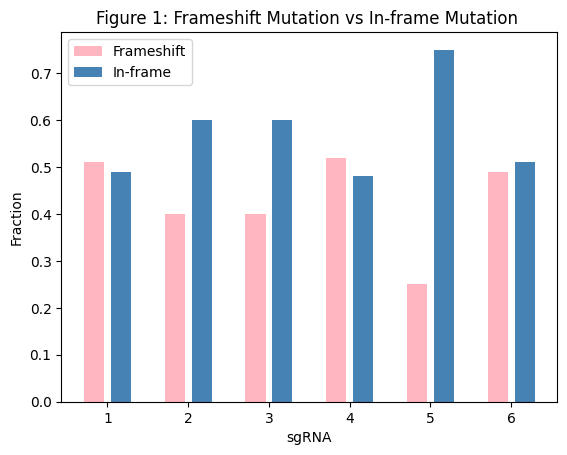

In [42]:
# Barplot that shows the distribution of frameshift and in-frame mutations for the Monte Carlo generated data
  # Should look like the real data in S2,B

w, x = 0.25, np.arange(len(sgrna)) # width and position for bars

fig, ax = plt.subplots()
ax.bar(x - w/1.5, fraction_frameshift_sim, width=w, label='Frameshift', color = "lightpink") # x - w/2 determines the x-position of the bar for frameshift
ax.bar(x + w/1.5, fraction_inframe_sim, width=w, label='In-frame', color = "steelblue") # # x + w/2 determines the x-position of the bar for in-frame

ax.set_xticks(x)
ax.set_xticklabels(sgrna)
ax.set_ylabel('Fraction')
ax.set_xlabel("sgRNA")
ax.set_title('Figure 1: Frameshift Mutation vs In-frame Mutation ')
ax.legend()

plt.show()

#Backward simulation - NLL

In [43]:
# Functions to calculate the factorial and binomial distribution

def factorial(x):
    """x! as a product, 0! = 1."""

    total = 1
    for k in range(1, x + 1):
        total = total * k
    return total

def binomial(n, p, k):
  """ Binomial distribution """

  formula = factorial(n) * p ** k * (1 - p) ** (n - k)/ (factorial(k)* factorial(n-k))
  return formula

In [44]:
# Function that retreives the index of the smallest value in a list and a function that calculates the negative log likelihood (NLL) for a given p

def position_of_min(values):
    """The position of the smallest value in the list."""
    best = 0
    for i in range(len(values)):
        if values[i] < values[best]:
            best = i
    return best

def nll(p):
    """ Minus the log of the likelihood. Calculates the nll for a candidate p with each number of frameshifts for every sgRNA """
    total = 0

    for frame in frameshift:
      total -= math.log(binomial(100, p, frame))

    return total

grid = [0.2 + 0.001 * i for i in range(601)] # Creates a grid of possible p values between 0.2 and 0.8
scores = [0.0] * len(grid)

for i in range(len(grid)): # Loops through the grid and calculates the nll for each p
  scores[i] = nll(grid[i])

p_hat = grid[position_of_min(scores)] # Finds the smallest value of nll

print("Estimated p-value (p_hat) using the negative log likelihood of the binomial distribution:", round((p_hat), 3))

Estimated p-value (p_hat) using the negative log likelihood of the binomial distribution: 0.435


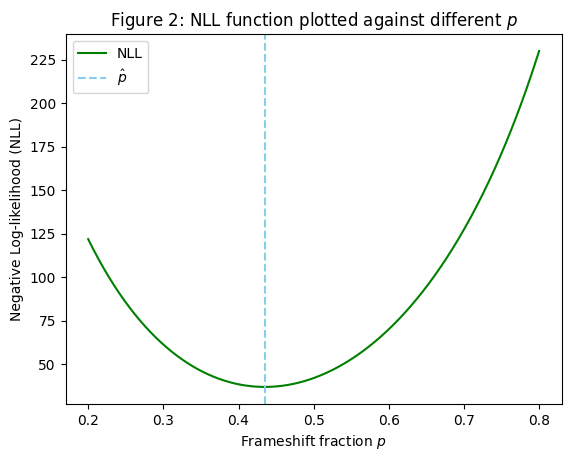

In [45]:
plt.plot(grid, scores, label = "NLL", color = "green")
plt.axvline(p_hat, ls="--", label = "$\\hat p$", color = "skyblue")
plt.title("Figure 2: NLL function plotted against different $p$")
plt.xlabel("Frameshift fraction $p$")
plt.ylabel("Negative Log-likelihood (NLL)")
plt.legend()
plt.show()

#Uncertainty estimation of parameter

In [46]:
# To determine the certainty of the p_hat estimation we calculate the curvature

h = 0.01

curvature = (nll(p_hat+h) - 2*nll(p_hat) + nll(p_hat-h)) / h**2 # estimated second derivative of nll minimum
se_p = 1/(curvature**0.5) # Standard deviation of p_hat

print("p_hat (at NLL minimum):", round(p_hat, 3), "±", round(se_p, 4))
print("Curvature of NLL minimum: ", round(curvature, 1))

p_hat (at NLL minimum): 0.435 ± 0.0202
Curvature of NLL minimum:  2441.8


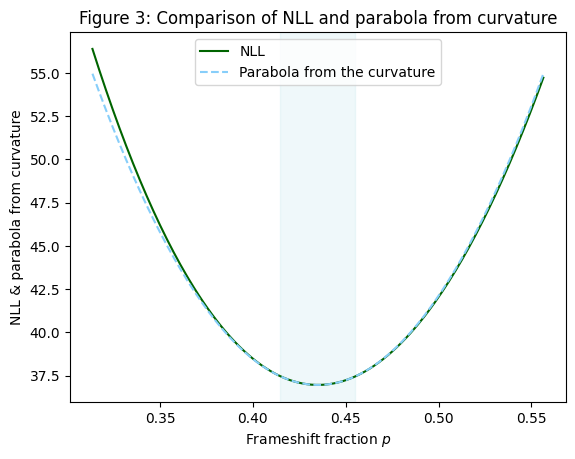

In [47]:
near = [p_hat - 6 * se_p + 12 * se_p * i / 200 for i in range(201)] # creates a range of p_hat ± 6 standard deviations

plt.plot(near, [nll(p) for p in near], label="NLL", color = "darkgreen")
plt.plot(near, [nll(p_hat) + 0.5 * curvature * (p - p_hat) ** 2 for p in near], "--",
         label="Parabola from the curvature",
         color = "lightskyblue")
plt.axvspan(p_hat - se_p, p_hat + se_p, alpha=0.2, color = "powderblue") # creates area of p_hat ± 1 standard deviation
plt.ylabel("NLL & parabola from curvature")
plt.xlabel("Frameshift fraction $p$")
plt.title("Figure 3: Comparison of NLL and parabola from curvature")
plt.legend()
plt.show()


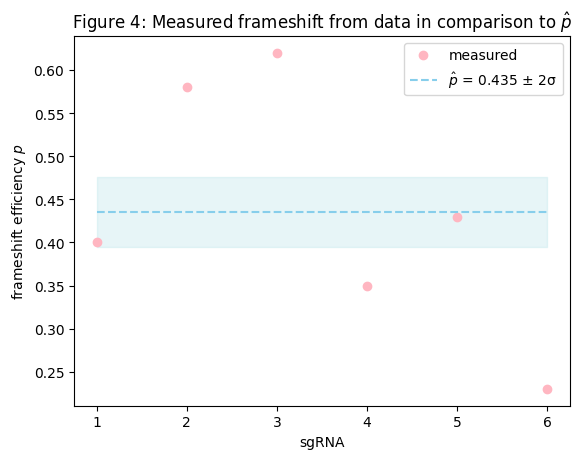

In [48]:
# Here we see the downfall of our model

p_hat_lst = [p_hat] * 6

low = p_hat - 2* se_p
high = p_hat + 2* se_p

plt.plot(sgrna, fraction_frameshift, "o", label="measured", color = "lightpink")
plt.plot(sgrna, p_hat_lst, "--",
         label=f"$\\hat p$ = {p_hat:.3f} $\\pm$ 2σ ",
         color = "skyblue")
plt.fill_between(sgrna, low, high, alpha=0.3, color = "powderblue")
plt.xlabel("sgRNA")
plt.ylabel("frameshift efficiency $p$")
plt.title("Figure 4: Measured frameshift from data in comparison to $\\hat p$")
plt.legend()
plt.show()

**Discussion of Figure 4:**

This figure shows the measured frameshift efficiency for each sgRNA, and the estimated *p̂* from the NLL approach together with its standard deviation derived from the curvature. As we can see the p̂ 95% interval only covers two of the measured datapoints, indicating that our model does not account for the variability of p between the sgRNAs. Adding more parameters would probably take this variation into account more. This is something that could be done in the future if we want to fit the data and mechanism better.